# PatchTST + XGBoost — NASA C-MAPSS Anomaly Detection

## Mimari
```
Sensor Sequence (T x F)
        |
    Patching  (T=30 -> 6 patch x 5 timestep)
        |
    Linear Projection -> d_model
        |
    [CLS] token + Positional Encoding
        |
    Transformer Encoder (multi-head self-attention)
        |
    CLS output -> embed_dim
        |
    Concat + Handcrafted Stats
        |
    XGBoost Classifier
```

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Kurulum & Import

In [2]:
!pip install -q xgboost

In [3]:
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
)
import xgboost as xgb

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 2. Konfigurasyon

In [4]:
BASE = '/content/drive/MyDrive/data'

CFG = {
    # Data
    'rul_threshold':   30,
    'seq_len':         30,
    'stride':          1,
    'val_engine_frac': 0.15,

    # PatchTST
    'patch_len':    5,      # her patch kac timestep
    'patch_stride': 5,      # overlap yok
    'd_model':      128,
    'n_heads':      8,
    'n_layers':     3,
    'ffn_dim':      256,
    'dropout':      0.1,
    'embed_dim':    128,

    # Egitim
    'epochs':       50,
    'batch_size':   512,
    'lr':           1e-3,
    'weight_decay': 1e-4,
    'patience':     10,
    'focal_gamma':  2.0,

    # XGBoost
    'xgb_rounds':    600,
    'xgb_lr':        0.05,
    'xgb_depth':     6,
    'xgb_subsample': 0.8,
    'xgb_colsample': 0.8,
    'xgb_min_child': 5,
    'xgb_reg_alpha': 0.1,
    'xgb_reg_lambda':1.0,
}

## 3. Veri Yukleme & On Isleme

In [5]:
COLUMNS = (
    ['unit_number', 'time_in_cycles']
    + [f'op_{i}' for i in range(1, 4)]
    + [f's{i}'  for i in range(1, 22)]
)
DROP_SENSORS = ['s1','s5','s6','s10','s16','s18','s19']


def load_raw(fd):
    train = pd.read_csv(f'{BASE}/train_{fd}.txt', sep=r'\s+', header=None, names=COLUMNS)
    test  = pd.read_csv(f'{BASE}/test_{fd}.txt',  sep=r'\s+', header=None, names=COLUMNS)
    rul   = pd.read_csv(f'{BASE}/RUL_{fd}.txt',   header=None, names=['RUL'])
    return train, test, rul


def add_rul(df):
    max_c = df.groupby('unit_number')['time_in_cycles'].max()
    df = df.join(max_c.rename('max_c'), on='unit_number')
    df['RUL'] = df['max_c'] - df['time_in_cycles']
    return df.drop('max_c', axis=1)


def get_features(df):
    sensors = [c for c in df.columns if c.startswith('s') and c not in DROP_SENSORS]
    return sensors + ['op_1','op_2','op_3']


def normalize(train_df, test_df, feat_cols):
    sc = StandardScaler()
    train_df, test_df = train_df.copy(), test_df.copy()
    train_df[feat_cols] = sc.fit_transform(train_df[feat_cols])
    test_df[feat_cols]  = sc.transform(test_df[feat_cols])
    return train_df, test_df


def make_sequences(df, feat_cols, rul_thr, seq_len, stride):
    X, y, uids = [], [], []
    for uid, grp in df.groupby('unit_number'):
        vals   = grp[feat_cols].values.astype(np.float32)
        labels = (grp['RUL'].values < rul_thr).astype(np.float32)
        n = len(vals)
        for s in range(0, n - seq_len + 1, stride):
            X.append(vals[s:s+seq_len])
            y.append(labels[s+seq_len-1])
            uids.append(uid)
    return np.array(X, np.float32), np.array(y), np.array(uids)


def make_test_sequences(test_df, rul_df, feat_cols, rul_thr, seq_len):
    X_last, y_last, X_all, y_all = [], [], [], []
    for uid, grp in test_df.groupby('unit_number'):
        vals     = grp[feat_cols].values.astype(np.float32)
        n        = len(vals)
        true_rul = rul_df.iloc[uid - 1]['RUL']
        label    = int(true_rul < rul_thr)

        if n >= seq_len:
            X_last.append(vals[-seq_len:])
        else:
            pad = np.zeros((seq_len - n, vals.shape[1]), np.float32)
            X_last.append(np.vstack([pad, vals]))
        y_last.append(label)

        for s in range(0, n - seq_len + 1):
            steps_left = n - (s + seq_len - 1) - 1
            X_all.append(vals[s:s+seq_len])
            y_all.append(int((true_rul + steps_left) < rul_thr))

    return (
        np.array(X_last, np.float32), np.array(y_last, np.int32),
        np.array(X_all,  np.float32), np.array(y_all,  np.int32),
    )


def extract_handcrafted(X):
    """(N, seq, F) -> (N, F*6)"""
    return np.concatenate([
        X.mean(axis=1),
        X.std(axis=1),
        X.min(axis=1),
        X.max(axis=1),
        X[:, -1, :] - X[:, 0, :],
        X.max(axis=1) - X.min(axis=1),
    ], axis=1).astype(np.float32)


def prepare_fd(fd, cfg=CFG):
    train_raw, test_raw, rul_df = load_raw(fd)
    train_raw  = add_rul(train_raw)
    feat_cols  = get_features(train_raw)
    train_raw, test_raw = normalize(train_raw, test_raw, feat_cols)

    X, y, uids = make_sequences(
        train_raw, feat_cols, cfg['rul_threshold'], cfg['seq_len'], cfg['stride']
    )

    # Engine-based val split
    engines = np.unique(uids)
    rng     = np.random.RandomState(42)
    rng.shuffle(engines)
    n_val   = max(1, int(len(engines) * cfg['val_engine_frac']))
    val_set = set(engines[:n_val])

    val_mask = np.array([u in val_set for u in uids])
    X_tr, y_tr   = X[~val_mask], y[~val_mask]
    X_val, y_val = X[val_mask],  y[val_mask]

    X_tl, y_tl, X_tall, y_tall = make_test_sequences(
        test_raw, rul_df, feat_cols, cfg['rul_threshold'], cfg['seq_len']
    )

    hc_tr   = extract_handcrafted(X_tr)
    hc_val  = extract_handcrafted(X_val)
    hc_tl   = extract_handcrafted(X_tl)
    hc_tall = extract_handcrafted(X_tall)
    n_feat  = X.shape[2]

    print(f'  {fd} | tr={X_tr.shape} val={X_val.shape} | '
          f'tl={X_tl.shape} tall={X_tall.shape} | F={n_feat}  hc={hc_tr.shape[1]}')
    print(f'       pos  tr={y_tr.mean():.3f} val={y_val.mean():.3f} '
          f'tl={y_tl.mean():.3f} tall={y_tall.mean():.3f}')

    return dict(
        X_tr=X_tr, y_tr=y_tr, hc_tr=hc_tr,
        X_val=X_val, y_val=y_val, hc_val=hc_val,
        X_tl=X_tl,  y_tl=y_tl,  hc_tl=hc_tl,
        X_tall=X_tall, y_tall=y_tall, hc_tall=hc_tall,
        n_feat=n_feat,
    )

## 4. Model: PatchTST Encoder

In [6]:
class PatchEmbedding(nn.Module):
    """
    (B, T, F) -> (B, num_patches, d_model)
    Her patch: patch_len timestep x F sensor flatten,
    sonra d_model'e lineer projeksiyon.
    """
    def __init__(self, n_feat, patch_len, patch_stride, d_model):
        super().__init__()
        self.patch_len    = patch_len
        self.patch_stride = patch_stride
        self.proj         = nn.Linear(patch_len * n_feat, d_model)

    def forward(self, x):                                          # (B, T, F)
        patches = x.unfold(1, self.patch_len, self.patch_stride)   # (B, P, F, patch_len)
        patches = patches.permute(0, 1, 3, 2)                      # (B, P, patch_len, F)
        B, P, PL, F = patches.shape
        patches = patches.reshape(B, P, PL * F)                    # (B, P, patch_len*F)
        return self.proj(patches)                                   # (B, P, d_model)


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none'
        )
        prob = torch.sigmoid(logits)
        pt   = torch.where(targets == 1, prob, 1 - prob)
        return ((1 - pt) ** self.gamma * bce).mean()


class PatchTSTEncoder(nn.Module):
    """
    CLS token + Patch embedding -> Transformer -> CLS cikisi -> embed_dim
    """
    def __init__(self, n_feat, cfg):
        super().__init__()
        pl, ps = cfg['patch_len'], cfg['patch_stride']
        T, d   = cfg['seq_len'],   cfg['d_model']

        self.patch_embed = PatchEmbedding(n_feat, pl, ps, d)
        num_patches      = (T - pl) // ps + 1
        self.num_patches = num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, d) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d,
            nhead=cfg['n_heads'],
            dim_feedforward=cfg['ffn_dim'],
            dropout=cfg['dropout'],
            activation='gelu',
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=cfg['n_layers'])
        self.norm        = nn.LayerNorm(d)

        self.proj = nn.Sequential(
            nn.Linear(d, cfg['embed_dim']),
            nn.LayerNorm(cfg['embed_dim']),
            nn.GELU(),
            nn.Dropout(cfg['dropout']),
        )
        self.head = nn.Linear(cfg['embed_dim'], 1)
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):                               # (B, T, F)
        B      = x.shape[0]
        p      = self.patch_embed(x)                    # (B, P, d_model)
        cls    = self.cls_token.expand(B, -1, -1)       # (B, 1, d_model)
        tokens = torch.cat([cls, p], dim=1)             # (B, P+1, d_model)
        tokens = tokens + self.pos_embed

        out     = self.norm(self.transformer(tokens))   # (B, P+1, d_model)
        cls_out = out[:, 0]                             # (B, d_model)
        emb     = self.proj(cls_out)                    # (B, embed_dim)
        logit   = self.head(emb).squeeze(-1)            # (B,)
        return emb, logit

## 5. Egitim Dongusu (Phase 1 — PatchTST Pre-training)

In [7]:
def train_encoder(data, cfg=CFG, device=DEVICE):
    X_tr, y_tr   = data['X_tr'], data['y_tr']
    X_val, y_val = data['X_val'], data['y_val']

    tr_ds  = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr))
    val_ds = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))
    tr_loader  = DataLoader(tr_ds,  cfg['batch_size'], shuffle=True,  drop_last=True)
    val_loader = DataLoader(val_ds, cfg['batch_size'], shuffle=False)

    model = PatchTSTEncoder(data['n_feat'], cfg).to(device)
    print(f'  Patches/seq: {model.num_patches}  |  '
          f'Params: {sum(p.numel() for p in model.parameters()):,}')

    pos_w = torch.tensor(
        [(1 - y_tr.mean()) / (y_tr.mean() + 1e-6)], dtype=torch.float32
    ).to(device)
    criterion = FocalLoss(gamma=cfg['focal_gamma'], pos_weight=pos_w)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay']
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])

    best_val, best_state, patience_cnt = float('inf'), None, 0

    for epoch in range(1, cfg['epochs'] + 1):
        model.train()
        tr_loss = 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            _, logit = model(xb)
            loss = criterion(logit, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tr_loss += loss.item() * len(xb)
        tr_loss /= len(tr_ds)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                _, logit = model(xb)
                val_loss += criterion(logit, yb).item() * len(xb)
        val_loss /= len(val_ds)
        scheduler.step()

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch {epoch:03d}/{cfg["epochs"]}  '
                  f'tr={tr_loss:.4f}  val={val_loss:.4f}')

        if val_loss < best_val - 1e-4:
            best_val     = val_loss
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= cfg['patience']:
                print(f'  Early stop @ epoch {epoch}')
                break

    model.load_state_dict(best_state)
    model.eval()
    print(f'  Best val_loss = {best_val:.4f}')
    return model


def extract_embeddings(model, X, device=DEVICE, batch_size=1024):
    model.eval()
    embs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i+batch_size]).to(device)
            emb, _ = model(xb)
            embs.append(emb.cpu().numpy())
    return np.vstack(embs)

## 6. XGBoost Asamasi (Phase 2)

In [8]:
def best_threshold(y_true, proba):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.05, 0.95, 0.01):
        f1 = f1_score(y_true, (proba >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1


def train_xgboost(emb_tr, hc_tr, y_tr, emb_val, hc_val, y_val, cfg=CFG):
    X_tr  = np.concatenate([emb_tr,  hc_tr],  axis=1)
    X_val = np.concatenate([emb_val, hc_val], axis=1)

    pos_ratio = y_tr.sum() / len(y_tr)
    spw = (1 - pos_ratio) / (pos_ratio + 1e-6)

    dtrain = xgb.DMatrix(X_tr,  label=y_tr)
    dval   = xgb.DMatrix(X_val, label=y_val)

    params = {
        'objective':        'binary:logistic',
        'eval_metric':      'logloss',
        'learning_rate':    cfg['xgb_lr'],
        'max_depth':        cfg['xgb_depth'],
        'subsample':        cfg['xgb_subsample'],
        'colsample_bytree': cfg['xgb_colsample'],
        'min_child_weight': cfg['xgb_min_child'],
        'reg_alpha':        cfg['xgb_reg_alpha'],
        'reg_lambda':       cfg['xgb_reg_lambda'],
        'scale_pos_weight': spw,
        'seed': 42,
        'verbosity': 0,
        'tree_method': 'hist',
        'device': 'cuda' if DEVICE == 'cuda' else 'cpu',
    }

    bst = xgb.train(
        params, dtrain,
        num_boost_round=cfg['xgb_rounds'],
        evals=[(dval, 'val')],
        early_stopping_rounds=30,
        verbose_eval=50,
    )

    val_proba = bst.predict(dval)
    thr, val_f1 = best_threshold(y_val, val_proba)
    val_auc = roc_auc_score(y_val, val_proba)
    print(f'  threshold={thr:.4f}  val_F1={val_f1:.4f}  val_AUC={val_auc:.4f}')
    return bst, thr


def evaluate(bst, thr, emb, hc, y_true, tag):
    X     = np.concatenate([emb, hc], axis=1)
    proba = bst.predict(xgb.DMatrix(X))
    pred  = (proba >= thr).astype(int)

    f1    = f1_score(y_true, pred, zero_division=0)
    auc   = roc_auc_score(y_true, proba)
    prauc = average_precision_score(y_true, proba)
    cm    = confusion_matrix(y_true, pred)
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2, 2) else (0, 0, 0, 0)

    print(f'  [{tag}]  F1={f1:.4f}  AUC={auc:.4f}  PR-AUC={prauc:.4f}  '
          f'TP={tp}  FP={fp}  FN={fn}')
    print(classification_report(y_true, pred,
                                target_names=['normal','anomaly'], digits=4))
    return f1, auc, prauc, tp, fp, fn

## 7. Tam Pipeline — Tum Dataset'ler

In [9]:
DATASETS = ['FD001', 'FD002', 'FD003', 'FD004']
summary  = []

for fd in DATASETS:
    print('\n' + '='*65)
    print(f'  {fd}')
    print('='*65)

    data = prepare_fd(fd, CFG)

    print('\n[Phase 1] PatchTST pre-training...')
    encoder = train_encoder(data, CFG, DEVICE)

    print('\n[Embedding extraction]')
    emb_tr   = extract_embeddings(encoder, data['X_tr'],   DEVICE)
    emb_val  = extract_embeddings(encoder, data['X_val'],  DEVICE)
    emb_tl   = extract_embeddings(encoder, data['X_tl'],   DEVICE)
    emb_tall = extract_embeddings(encoder, data['X_tall'], DEVICE)
    total_feat = emb_tr.shape[1] + data['hc_tr'].shape[1]
    print(f'  emb={emb_tr.shape[1]}  hc={data["hc_tr"].shape[1]}  total={total_feat}')

    print('\n[Phase 2] XGBoost training...')
    bst, thr = train_xgboost(
        emb_tr,  data['hc_tr'],  data['y_tr'],
        emb_val, data['hc_val'], data['y_val'],
        CFG,
    )

    print(f'\n[Evaluation — {fd}]')
    f1_tl,   auc_tl,   prauc_tl,  tp_tl,  fp_tl,  fn_tl  = evaluate(
        bst, thr, emb_tl,   data['hc_tl'],   data['y_tl'],   f'{fd} test_last')
    f1_tall, auc_tall, prauc_tall, tp_tall, fp_tall, fn_tall = evaluate(
        bst, thr, emb_tall, data['hc_tall'], data['y_tall'], f'{fd} test_all')

    summary.append({
        'Dataset':       fd,
        'F1 last':       round(f1_tl,    4),
        'AUC last':      round(auc_tl,   4),
        'PR-AUC last':   round(prauc_tl, 4),
        'TP/FP/FN last': f'{tp_tl}/{fp_tl}/{fn_tl}',
        'F1 all':        round(f1_tall,    4),
        'AUC all':       round(auc_tall,   4),
        'PR-AUC all':    round(prauc_tall, 4),
    })

    del encoder
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

print('\n' + '='*80)
print('  OZET TABLO — PatchTST + XGBoost')
print('='*80)
df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))
print('='*80)


  FD001
  FD001 | tr=(15104, 30, 17) val=(2627, 30, 17) | tl=(100, 30, 17) tall=(10196, 30, 17) | F=17  hc=102
       pos  tr=0.169 val=0.171 tl=0.250 tall=0.030

[Phase 1] PatchTST pre-training...
  Patches/seq: 6  |  Params: 426,625
  Epoch 001/50  tr=0.1322  val=0.0520
  Epoch 005/50  tr=0.0330  val=0.0432
  Epoch 010/50  tr=0.0213  val=0.0823
  Early stop @ epoch 12
  Best val_loss = 0.0391

[Embedding extraction]
  emb=128  hc=102  total=230

[Phase 2] XGBoost training...
[0]	val-logloss:0.64843
[50]	val-logloss:0.09903
[100]	val-logloss:0.07049
[150]	val-logloss:0.06933
[179]	val-logloss:0.07054
  threshold=0.7100  val_F1=0.9392  val_AUC=0.9962

[Evaluation — FD001]
  [FD001 test_last]  F1=0.9200  AUC=0.9915  PR-AUC=0.9738  TP=23  FP=2  FN=2
              precision    recall  f1-score   support

      normal     0.9733    0.9733    0.9733        75
     anomaly     0.9200    0.9200    0.9200        25

    accuracy                         0.9600       100
   macro avg     0.9467

## 8. Ozet Gorsellestirme

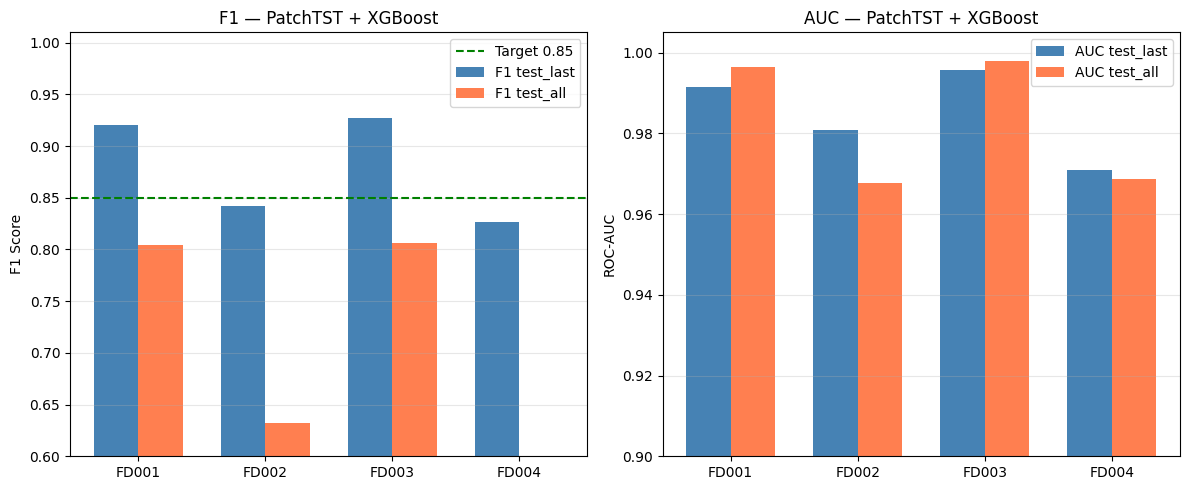

Kaydedildi: /content/patchtst_xgboost_results.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ds_labels = df_summary['Dataset'].tolist()
x = np.arange(len(ds_labels))
w = 0.35

ax = axes[0]
ax.bar(x - w/2, df_summary['F1 last'], w, label='F1 test_last', color='steelblue')
ax.bar(x + w/2, df_summary['F1 all'],  w, label='F1 test_all',  color='coral')
ax.axhline(0.85, ls='--', color='green', lw=1.5, label='Target 0.85')
ax.set_xticks(x); ax.set_xticklabels(ds_labels)
ax.set_ylim(0.6, 1.01); ax.set_ylabel('F1 Score')
ax.set_title('F1 — PatchTST + XGBoost')
ax.legend(); ax.grid(axis='y', alpha=0.3)

ax = axes[1]
ax.bar(x - w/2, df_summary['AUC last'], w, label='AUC test_last', color='steelblue')
ax.bar(x + w/2, df_summary['AUC all'],  w, label='AUC test_all',  color='coral')
ax.set_xticks(x); ax.set_xticklabels(ds_labels)
ax.set_ylim(0.9, 1.005); ax.set_ylabel('ROC-AUC')
ax.set_title('AUC — PatchTST + XGBoost')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/patchtst_xgboost_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Kaydedildi: /content/patchtst_xgboost_results.png')